In [1]:
import io, os, json, glob, re, time
from collections import OrderedDict, Counter

import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from concurrent.futures import ThreadPoolExecutor, as_completed
import threading

import openai
from openai import OpenAI

import ipywidgets as widgets
import matplotlib.pyplot as plt
from IPython.display import display, clear_output

from socialLLM_ConceptARC import *

In [2]:
# run the python file

# nohup python -u socialLLM_ConceptARC.py --model deepseek-chat --rule_name social_simple --temperature_type t1 > social_simple1.out &
# nohup python -u socialLLM_ConceptARC.py --model deepseek-chat --rule_name social_rule --temperature_type t1 > social_rule1.out &
# nohup python -u socialLLM_ConceptARC.py --model deepseek-chat --rule_name social_simple --temperature_type t2 > social_simple2.out &
# nohup python -u socialLLM_ConceptARC.py --model deepseek-chat --rule_name social_rule --temperature_type t2 > social_rule2.out &
# nohup python -u socialLLM_ConceptARC.py --model deepseek-chat --rule_name social_simple --temperature_type t3 > social_simple3.out &
# nohup python -u socialLLM_ConceptARC.py --model deepseek-chat --rule_name social_rule --temperature_type t3 > social_rule3.out &

### Main

#### indv parallel check

In [57]:
# --------------------------
# 설정
# --------------------------
#MODEL = 'deepseek-chat'
MODEL = "gpt-5-mini"
TEMPERATURE = 1.0
NUM_REPEATS = 10   # 같은 문제에 대해 10번 샷
RULE_NAME = "indv_simple_parallel"

LOG_DIR = os.path.join("log_temp_chk", MODEL)
os.makedirs(LOG_DIR, exist_ok=True)


In [58]:
# 🔹 진행 상황 로그 파일
PROGRESS_LOG_DIR = "log_progress"
PROGRESS_LOG_PATH = os.path.join(PROGRESS_LOG_DIR, f"log_{MODEL}_{RULE_NAME}2.txt")

# 🔹 여러 thread가 같이 쓰니까 lock
progress_lock = threading.Lock()

def log_progress(message: str):
    """공용 progress log 파일에 thread-safe하게 한 줄씩 append."""
    line = f"[{time.strftime('%Y-%m-%d %H:%M:%S')}] {message}\n"
    with progress_lock:
        with open(PROGRESS_LOG_PATH, "a", encoding="utf-8") as f:
            f.write(line)

# --------------------------
# 문제 목록 가져오기
# --------------------------
prefix = (
    "Find the common rule that maps an input grid to an output grid, given the examples below.\n"
)

suffix = (
    "Below is a test input grid. Predict the corresponding output grid by applying the rule you found. Return only this minified JSON (no markdown, no extra keys): {\"grid\":\"<final grid>\"}"
)

number_range = list(range(10))   # 각 폴더마다 10 문제
#number_range = [0, 5, 9]
case_range = [0, 1, 2]                 # test case 3개

problems = list(problem_generator(
    prefix=prefix,
    suffix=suffix,
    number_range=number_range,
    case_range=case_range
))
print("Total problems:", len(problems))

TOTAL_PROBLEMS = len(problems)
# 전체 문제 수를 progress log에 남김
log_progress(f"Experiment {RULE_NAME} started. TOTAL_PROBLEMS={TOTAL_PROBLEMS}, NUM_REPEATS={NUM_REPEATS}")

Total problems: 480


In [59]:
def parse_output_json(response: str) -> str:
    """
    simple setting용 파서.
    LLM 응답 전체 텍스트에서 마지막으로 등장하는 "grid":"..."를 뽑아서
    grid 문자열을 반환한다.

    - "grid":"...여러줄..." 꼴도 허용 (DOTALL)
    - 중간에 {5}, {8,0} 같은 중괄호들이 있어도 전혀 신경 쓰지 않음
    - 만약 "grid"를 아예 못 찾으면, 전체 텍스트를 그대로 grid로 반환 (fallback)
    """
    if response is None:
        return "", ""

    text = str(response).strip()

    # -------------------------------
    # 1) 정상 패턴: "grid":"...여러줄..."
    #    여러 번 나올 수 있으니 "마지막" 매치를 사용
    # -------------------------------
    grid_matches = list(re.finditer(r'"grid"\s*:\s*"(.*?)"', text, flags=re.S))
    if grid_matches:
        grid = grid_matches[-1].group(1).strip()
        return "", grid

    # -------------------------------
    # 2) 불완전한 "grid" (따옴표가 안 닫히거나, 끝이 잘린 경우) 처리
    #    -> 마지막 "grid" 이후를 통으로 보고, 뒷부분 정리해서 사용
    # -------------------------------
    idx = text.rfind('"grid"')
    if idx != -1:
        sub = text[idx:]
        # '"grid": " ...' 이후를 통으로 잡는다.
        m = re.search(r'"grid"\s*:\s*"(.*)', sub, flags=re.S)
        if m:
            g = m.group(1)
            # 뒤에 ``` 코드펜스가 있으면 그 앞까지만 사용
            g = re.split(r'```', g, 1)[0]
            g = g.rstrip()
            # 맨 끝에 붙어 있을 수 있는 "나 }를 제거
            g = re.sub(r'["}]+$', "", g).rstrip()
            if g:
                return "", g

    # -------------------------------
    # 3) 여기까지 왔으면 "grid"를 못 찾은 것 → 전체 텍스트를 grid로
    # -------------------------------
    return text


# --------------------------
# response에서 rule, output 부분을 파싱
# --------------------------
def parse_rule_and_output_json(response: str):
    """
    LLM 응답 문자열에서 {"rule": "...", "grid": "..."} 형태를 최대한 robust하게 뽑아낸다.
    - JSON이 제대로 되어 있으면 json.loads로 처리
    - grid 안에 실제 개행이 있는 "가짜 JSON", 불완전 JSON, ```json{...``` 같은 것도
      정규식으로 rule / grid를 직접 뽑는다.
    - 실패하면 (rule="", grid=전체 텍스트)로 fallback
    """
    if response is None:
        return "", ""

    text = str(response).strip()
    rule = ""
    grid = text  # 최종 fallback: 전체 텍스트를 grid로 본다

    # -------------------------------
    # 1) 마지막 { ... } 덩어리를 JSON으로 한 번 시도
    # -------------------------------
    try:
        start = text.rfind("{")
        end = text.rfind("}")
        if start != -1 and end != -1 and start < end:
            candidate = text[start:end+1].strip()
        else:
            candidate = text

        obj = json.loads(candidate)
        rule = str(obj.get("rule", "")).strip()
        grid = str(obj.get("grid", grid)).strip()
        return rule, grid  # 여기까지 왔으면 정상 JSON
    except Exception:
        # 정상 JSON이 아니면 정규식으로 수동 파싱
        pass

    # -------------------------------
    # 2) 정규식으로 "rule" 뽑기 (가장 마지막 것 사용)
    # -------------------------------
    rule_matches = list(re.finditer(r'"rule"\s*:\s*"(.*?)"', text, flags=re.S))
    if rule_matches:
        rule = rule_matches[-1].group(1).strip()
    else:
        rule = ""

    # -------------------------------
    # 3) 정규식으로 "grid" 뽑기 (가장 마지막 것 사용)
    #    3-1) 먼저 정상 패턴: "grid":"...여러줄..."
    # -------------------------------
    grid_matches = list(re.finditer(r'"grid"\s*:\s*"(.*?)"', text, flags=re.S))
    if grid_matches:
        grid = grid_matches[-1].group(1).strip()
        return rule, grid

    # -------------------------------
    # 3-2) 불완전한 "grid" (끝이 잘린 경우) 처리
    # -------------------------------
    idx = text.rfind('"grid"')
    if idx != -1:
        sub = text[idx:]
        m = re.search(r'"grid"\s*:\s*"(.*)', sub, flags=re.S)
        if m:
            g = m.group(1)
            # 뒤에 코드펜스가 있으면 그 앞까지만
            g = re.split(r'```', g, 1)[0]
            g = g.rstrip()
            # 맨 끝에 붙은 "나 }를 제거
            g = re.sub(r'["}]+$', "", g).rstrip()
            if g:
                grid = g

    return rule, grid

# --------------------------
# worker 함수
# --------------------------
def worker_run(worker_id: int, rule_name: str):

    agent = LLMAgent(
        name=f"Worker{worker_id}",
        model=MODEL,
        temperature=TEMPERATURE,
        extract_answer=extract_answer,
    )

    log_progress(f"Worker {worker_id} started. TOTAL_PROBLEMS={TOTAL_PROBLEMS}")
    
    parse = lambda x: parse_rule_and_output_json(x) if "rule" in rule_name else parse_output_json(x)

    out = []
    for idx, (pname, _, prompt, label) in enumerate(problems):

        # 🔹 여기가 진행상황 로그 포인트
        log_progress(
            f"Worker {worker_id} processing problem {idx+1}/{TOTAL_PROBLEMS} ({pname})"
        )

        messages = [
            agent.construct_user_message(prompt),
        ]

        try:
            raw, ans, ptok, ctok = agent.generate_answer(messages)
        except Exception as e:
            log_progress(f"Worker {worker_id} ERROR at {pname}: {e}")
            raw = ""
            ans = ""
            ptok = ctok = 0

        rule_text, grid_text = parse(raw)
        
        out.append({
            "worker": worker_id,
            "problem_name": pname,
            "problem_index": idx,
            "prompt": prompt,
            "label": label,
            "raw_response": raw,
            "rule": rule_text,
            "grid": grid_text,
            "prompt_tokens": ptok,
            "completion_tokens": ctok,
            "timestamp": time.time()
        })

    path = os.path.join(LOG_DIR, f"{RULE_NAME}_worker{worker_id}.json")
    with open(path, "w", encoding="utf-8") as f:
        json.dump(out, f, indent=2, ensure_ascii=False)

    log_progress(f"Worker {worker_id} finished. Saved -> {path}")
    return path


In [ ]:

# --------------------------
# 병렬 실행
# --------------------------
with ThreadPoolExecutor(max_workers=NUM_REPEATS) as ex:
    futures = [ex.submit(worker_run, w, rule_name=RULE_NAME) for w in [5, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19]]
    for f in as_completed(futures):
        f.result()

log_progress(f"Experiment {RULE_NAME} finished for all workers.")
print("Done.")

### Stat

In [2]:
# --------------------------
# 설정
# --------------------------

MODEL = "deepseek-chat"
#MODEL = "gpt-5-mini"
TEMPERATURE = 1.0
NUM_REPEATS = 10   # 같은 문제에 대해 10번 샷
RULE_NAME = "indv_simple_parallel"

LOG_DIR = os.path.join("log_temp_chk", MODEL)

In [4]:
# -------------------------
# 로그 읽기
# -------------------------
files = glob.glob(os.path.join(LOG_DIR, f"{RULE_NAME}_worker*.json"))
records = []
for fp in files:
    with open(fp, encoding="utf-8") as f:
        records.extend(json.load(f))

from collections import defaultdict
by_prob = defaultdict(list)
for r in records:
    by_prob[r["problem_name"]].append(r)

# -------------------------
# 문제별 통계
# -------------------------
stats = {}

for pname, lst in by_prob.items():

    label_arr = extract_answer_array(lst[0]["label"])
    ans_arrays = []
    accs = []
    dists = []
    rules = []

    for r in lst:
        out_arr = extract_answer_array(r["output_grid"], label_arr.shape)
        #out_arr = extract_answer_array(r["grid"], label_arr.shape)
        ans_arrays.append(out_arr)
        rules.append(r["rule"])
        accs.append(int((out_arr == label_arr).all()))
        dists.append(1-float((out_arr == label_arr).mean()))

    uniq = len({np.array(a).tobytes() for a in ans_arrays})

    stats[pname] = dict(
        label_arr=label_arr,
        ans_arrays=ans_arrays,
        accuracies=accs,
        distances=dists,
        rules=rules,
        uniq=uniq,
        var=float(np.var(accs)),
    )

In [8]:
prefix = "Complete the given pattern. "
suffix = "Only give the answer, no other text or explanation. "

generator = problem_generator(prefix=prefix, suffix=suffix, number_range=range(10), case_range=range(3))

problem_list = []
for i in range(16 * 10 * 3):  # 16 folders, 10 files per folder, 3 problems per file
    problem_name, problem, problem_prompt, label = next(generator)
    problem_list.append((problem_name, problem))
    
# 🔹 여기 한 줄 추가
problem_dict = dict(problem_list)

# -------------------------
# 카테고리 추출 (폴더 prefix)
# -------------------------
def get_cat(p):
    return re.sub(r"\d+_\d+$", "", p)

cats = sorted({get_cat(p) for p in stats})
prob_by_cat = defaultdict(list)
for p in stats:
    prob_by_cat[get_cat(p)].append(p)

# -------------------------
# helper plt
# -------------------------
def show_grid(arr, title=None):
    plt.figure(dpi=200)
    plt.imshow(arr, interpolation="nearest")
    if title: plt.title(title)
    plt.xticks([]); plt.yticks([])
    plt.colorbar()
    plt.show()

def visualize_problem(problems, cmap):
    # define colormap that maps 0-9 independently, where 0 is black.

    # draw coordinator.problem[i][j] where 0<=i<=3 and `0<=j<=2` into 3x2 subplots
    problem_name = problems[0]  # Extract the problem name from the tuple (problem_name, problem)
    problems = problems[1]  # Extract the problem part from the tuple (problem_name, problem)
    fig, axs = plt.subplots(len(problems), 2, figsize=(5, 8), dpi=200)
    fig.suptitle(f'{problem_name}', fontsize=16)
    vmin, vmax = 0, 8
    for i in range(len(problems)):
        for j in range(2):
            if i < len(problems) and j < len(problems[i]):
                array = np.array(problems[i][j])
                ax = axs[i, j]
                ax.imshow(array, cmap=cmap, vmin=0, vmax=9)
                ax.set_title(f'{"Problem" if j==0 else "Answer"} {i+1}')
                #axs[i, j].axis('off')
                
                H, W = array.shape
                ax.set_xticks(np.arange(-0.5, W, 1))
                ax.set_yticks(np.arange(-0.5, H, 1))
                ax.grid(color='gray', linestyle='-', linewidth=0.5)

                ax.tick_params(
                        axis='both',
                        which='both',
                        length=0,
                        labelbottom=False,
                        labeltop=False,
                        labelleft=False,
                        labelright=False
                    )

                for spine in ax.spines.values():
                    spine.set_visible(False) 

    plt.tight_layout()
    
dataset_folder = "dataset/ConceptARC"
folders = [f for f in os.listdir(dataset_folder) if os.path.isdir(os.path.join(dataset_folder, f))]
folders.sort()
folder_name_dict = {name:int(i*30) for i, name in enumerate(folders)}

# -------------------------
# 위젯 구성
# -------------------------
view = widgets.ToggleButtons(options=["By problem", "By category", "Overall"], description="View")
dd_prob = widgets.Dropdown(options=sorted(stats.keys()), description="Problem")
dd_cat = widgets.Dropdown(options=cats, description="Category")
out = widgets.Output()

from matplotlib.colors import ListedColormap, hsv_to_rgb

def make_arc_cmap():
    # 0 → black
    colors = [(0, 0, 0)]  
    
    hues = np.linspace(0, 0.8, 9, endpoint=False)[::-1]

    # HSV → RGB 변환
    hsv_colors = np.stack([hues, np.ones(9), np.ones(9)], axis=1)  # (H, S=1, V=1)
    rgb_colors = hsv_to_rgb(hsv_colors)

    colors.extend(rgb_colors)

    return ListedColormap(colors)


# 사용 예시
arc_cmap = make_arc_cmap()

'''

colors = [(0, 0, 0)]
hues = np.linspace(0, 1, 9, endpoint=False)[::-1]
hsv_colors = np.stack([hues, np.ones(9), np.ones(9)], axis=1)  # (H, S=1, V=1)
rgb_colors = hsv_to_rgb(hsv_colors)
colors.extend(rgb_colors)
colors2 = [colors[i] for i in [8, 9, 0, 7, 4, 5, 6, 3, 2, 1]]
arc_cmap = ListedColormap(colors2)
'''

def update(*_):
    with out:
        clear_output()

        if view.value == "By problem":
            pname = dd_prob.value
            s = stats[pname]

            # 🔹 [추가] 해당 문제의 전체 grid(예시 + test)를 먼저 시각화
            # problem_dict[pname] 은 (input, output) 쌍이 담긴 list
            visualize_problem((pname, problem_dict[pname]), arc_cmap)

            # 🔹 기존 텍스트 정보 출력
            print("Problem:", pname, "Category:", get_cat(pname))
            print("Accuracies:", s["accuracies"])
            # format distances to 3 decimal places
            print("Distances:", [f"{d:.2f}" for d in s["distances"]])
            print("Mean:", np.mean(s["accuracies"]))
            print("Variance:", s["var"])
            print("Unique outputs:", s["uniq"])

            # 🔹 기존 ground truth + accuracy histogram figure
            fig, axs = plt.subplots(1, 2, figsize=(10, 4), dpi=200)
            axs[0].imshow(s["label_arr"], cmap=arc_cmap, vmin=0, vmax=9)
            axs[0].set_title("Ground Truth")
            axs[0].set_xticks([]); axs[0].set_yticks([])
            axs[1].hist(s["distances"], bins=np.linspace(0,1,11))
            axs[1].set_title("Distance histogram")
            
            H, W = s["label_arr"].shape
            axs[0].set_xticks(np.arange(-0.5, W, 1))
            axs[0].set_yticks(np.arange(-0.5, H, 1))
            axs[0].grid(color='gray', linestyle='-', linewidth=0.5)

            axs[0].tick_params(
                    axis='both',
                    which='both',
                    length=0,
                    labelbottom=False,
                    labeltop=False,
                    labelleft=False,
                    labelright=False
                )

            for spine in axs[0].spines.values():
                spine.set_visible(False) 
            
            
            plt.show()

            # 🔹 기존 Rule & Output accordion
            children = []
            titles = []
            for i, (rule, arr) in enumerate(zip(s["rules"], s["ans_arrays"])):
                if arr is None:
                    arr = np.ones_like(s["label_arr"], dtype=int) * -1
                else:
                    arr = np.array(arr)
                #print(arr)
                fig, ax = plt.subplots(figsize=(4, 4), dpi=200)
                im = ax.imshow(arr, cmap=arc_cmap, vmin=0, vmax=9)
                ax.set_title(f"Output Grid #{i+1}")
                
                H, W = arr.shape
                ax.set_xticks(np.arange(-0.5, W, 1))
                ax.set_yticks(np.arange(-0.5, H, 1))
                ax.grid(color='gray', linestyle='-', linewidth=0.5)

                ax.tick_params(
                        axis='both',
                        which='both',
                        length=0,
                        labelbottom=False,
                        labeltop=False,
                        labelleft=False,
                        labelright=False
                    )

                for spine in ax.spines.values():
                    spine.set_visible(False)

                buf = io.BytesIO()
                fig.savefig(buf, format='png')
                buf.seek(0)
                img = widgets.Image(value=buf.getvalue(), format='png')
                children.append(img)
                plt.close(fig)

                titles.append(f"Rule #{i+1}:\n{rule}")
            acc = widgets.Accordion(children=children)
            for i, t in enumerate(titles):
                acc.set_title(i, t)
            display(acc)

        elif view.value == "By category":
            cat = dd_cat.value
            pnames = prob_by_cat[cat]

            all_acc = []
            all_dist = []
            uniq_list = []

            for p in pnames:
                all_acc.extend(stats[p]["accuracies"])
                all_dist.extend(stats[p]["distances"])
                uniq_list.append(stats[p]["uniq"])

            all_acc = np.array(all_acc)
            all_dist = np.array(all_dist)
            uniq_list = np.array(uniq_list)

            print("Category:", cat)
            print("Mean accuracy:", all_acc.mean())
            print("Var accuracy:", all_acc.var())
            print("Mean distance:", np.mean(all_dist))
            print("Var distance:", np.var(all_dist))
            print("Mean unique per problem:", uniq_list.mean())

            # merge accuracy and distance histograms
            plt.figure(figsize=(12, 4), dpi=200)
            plt.subplot(1, 2, 1)
            plt.hist(all_acc, bins=np.linspace(0,1,11))
            plt.title(f"Accuracy distribution: {cat}")

            plt.subplot(1, 2, 2)
            plt.hist(all_dist, bins=np.linspace(0,1,11))
            plt.title(f"Distance distribution: {cat}")
            plt.show()
            
            plt.figure(figsize=(8,3), dpi=200)
            # make bar color red for 3k, blue for 3k+1, green for 3k+2
            colors = ['red' if i % 3 == 0 else 'blue' if i % 3 == 1 else 'green' for i in range(len(pnames))]
            plt.bar(range(len(pnames)), np.mean(all_acc.reshape(len(pnames), -1), axis=1), color=colors)
            plt.xticks(range(len(pnames)), pnames, rotation=90)
            plt.title("Accuracy per problem")
            plt.ylim(0, 1)
            plt.tight_layout()
            plt.show()
            
            plt.figure(figsize=(8,3), dpi=200)
            plt.bar(range(len(pnames)), np.mean(all_dist.reshape(len(pnames), -1), axis=1), color=colors)
            plt.xticks(range(len(pnames)), pnames, rotation=90)
            plt.title("Distance per problem")
            plt.ylim(0, 1)
            plt.tight_layout()
            plt.show()

            plt.figure(figsize=(8,3), dpi=200)
            plt.bar(range(len(pnames)), uniq_list)
            plt.xticks(range(len(pnames)), pnames, rotation=90)
            plt.title("Unique outputs per problem")
            plt.tight_layout()
            plt.show()
        
        else:  # Overall
            all_acc = []
            all_dist = []
            uniq_list = []

            for p in stats:
                all_acc.extend(stats[p]["accuracies"])
                all_dist.extend(stats[p]["distances"])
                uniq_list.append(stats[p]["uniq"])

            all_acc = np.array(all_acc)
            all_dist = np.array(all_dist)
            uniq_list = np.array(uniq_list)

            print("Overall Mean accuracy:", all_acc.mean())
            print("Overall Var accuracy:", all_acc.var())
            print("Overall Mean distance:", np.mean(all_dist))
            print("Overall Var distance:", np.var(all_dist))
            print("Overall Mean unique per problem:", uniq_list.mean())

            category_acc = defaultdict(list)
            for p in stats:
                cat = get_cat(p)
                category_acc[cat].extend(stats[p]["accuracies"])

            # visualize mean and var accuracies for each category with errorbar
            fig, ax = plt.subplots(figsize=(10, 6), dpi=200)
            
            categories = list(category_acc.keys())
            mean_acc = [np.mean(category_acc[cat]) for cat in categories]
            var_acc = [np.var(category_acc[cat]) for cat in categories]
            ax.bar(categories, mean_acc, yerr=var_acc, capsize=5)
            ax.set_ylabel("Mean Accuracy")
            ax.set_title("Mean and Variance of Accuracies by Category")
            plt.xticks(rotation=45)
            plt.tight_layout()
            plt.show()

            # merge accuracy and distance histograms
            plt.figure(figsize=(12, 4), dpi=200)
            plt.subplot(1, 2, 1)
            plt.hist(all_acc, bins=np.linspace(0,1,11))
            plt.title(f"Overall Accuracy distribution")

            plt.subplot(1, 2, 2)
            plt.hist(all_dist, bins=np.linspace(0,1,11))
            plt.title(f"Overall Distance distribution")
            plt.show()


view.observe(update, names="value")
dd_prob.observe(update, names="value")
dd_cat.observe(update, names="value")

display(view, widgets.HBox([dd_prob, dd_cat]), out)
update()

#copy10_3

ToggleButtons(description='View', options=('By problem', 'By category', 'Overall'), value='By problem')

Output()

In [10]:
stats['Copy1_3']

{'label_arr': array([[2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2],
        [2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2],
        [2, 1, 1, 1, 1, 2, 2, 1, 1, 1, 1, 2],
        [2, 1, 1, 1, 1, 2, 2, 1, 1, 1, 1, 2],
        [2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2],
        [2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2]]),
 'ans_arrays': [array([[2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2],
         [2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2],
         [2, 1, 1, 1, 1, 2, 2, 1, 1, 1, 1, 2],
         [2, 1, 1, 1, 1, 2, 2, 1, 1, 1, 1, 2],
         [2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2],
         [2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2]]),
  array([[2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2],
         [2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2],
         [2, 1, 1, 1, 1, 2, 2, 1, 1, 1, 1, 2],
         [2, 1, 1, 1, 1, 2, 2, 1, 1, 1, 1, 2],
         [2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2],
         [2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2]]),
  array([[2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2],
         [2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2],
         [2, 1, 1, 1, 1, 2, 2, 1,

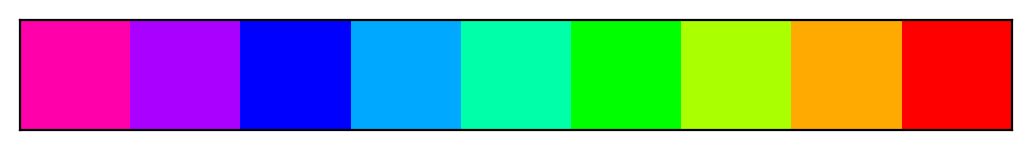

In [21]:
rgb_colors
# visualize
plt.figure(dpi=200)
plt.imshow(rgb_colors.reshape(1, -1, 3), interpolation="nearest")
plt.xticks([]); plt.yticks([])
plt.show()

In [8]:
category_acc = defaultdict(list)
for p in stats:
    cat = get_cat(p)
    category_acc[cat].extend(stats[p]["accuracies"])


In [11]:
categories = list(category_acc.keys())

In [51]:
pnames = prob_by_cat['AboveBelow']

all_acc = []
all_dist = []
uniq_list = []

for p in pnames:
    all_acc.extend(stats[p]["accuracies"])
    all_dist.extend(stats[p]["distances"])
    uniq_list.append(stats[p]["uniq"])

all_acc = np.array(all_acc)
all_dist = np.array(all_dist)
uniq_list = np.array(uniq_list)

#### Model output

In [ ]:
rule_name = 'social_simple_t1'
model_name = 'deepseek-chat'
num_agent = 5
max_turn = 3

dataset_folder = "dataset/ConceptARC"
folders = [f for f in os.listdir(dataset_folder) if os.path.isdir(os.path.join(dataset_folder, f))]
folders.sort()
folder_name_dict = {name:int(i*30) for i, name in enumerate(folders)}

prefix=''
suffix=''

generator = problem_generator(prefix=prefix, suffix=suffix, number_range=range(10), case_range=range(3))

problem_list = []
for i in range(16 * 10 * 3):  # 16 folders, 10 files per folder, 3 problems per file
    problem_name, problem, problem_prompt, label = next(generator)
    problem_list.append((problem_name, problem))

In [ ]:
folder_name_dict

In [ ]:
import ipywidgets as widgets

def update_plot(problem_name):
    with output:
        output.clear_output(wait=True)  # Clear previous plots
        display(problem_name)  # Optional: for debugging
        try:
            problem = problem_list[folder_name_dict[problem_name]]
            problem_name = problem[0]
            problem = problem[1]

            with open(f'log/{model_name}/log_{rule_name}_{model_name}_A{num_agent}_T{max_turn}_{problem_name}_0summary.json', 'r') as f:
                data = json.load(f)

            unique_answers = np.array(data["unique_answers"])
            answer_types = np.array(data["answer_types"])

            rows, cols = answer_types.shape
            fig, axes = plt.subplots(max(rows, len(problem)), cols+2, figsize=((cols+2) * 3, rows * 3))
            fig.suptitle(f'{problem_name} ({model_name}, {rule_name})', fontsize=24, y=1.0)

            vmin, vmax = -1, 10
            for i in range(max(len(problem), rows)):
                for j in range(2):
                    if i < len(problem):
                        array = np.array(problem[i][j])
                        axes[i, j].imshow(array, cmap='viridis', interpolation='nearest', vmin=vmin, vmax=vmax)
                        axes[i, j].set_title(f'{"Problem" if j==0 else "Answer"} {i+1}', fontsize=12, color='red' if i==len(problem)-1 else 'black')
                        axes[i, j].axis('off')
                    else:
                        axes[i, j].axis('off')

            for i in range(max(len(problem), rows)):
                for j in range(2, cols+2):
                    if i < rows:
                        idx = answer_types[i, j-2]
                        ax = axes[i, j]
                        im = ax.imshow(unique_answers[idx], cmap="viridis", vmin=vmin, vmax=vmax)
                        ax.set_xticks([])
                        ax.set_yticks([])
                        ax.spines[:].set_visible(False)
                        if i == 0:
                            ax.set_title(f"Agent {j+1}", fontsize=12)
                        if j == 2:
                            ax.set_ylabel(f"Turn {i}", rotation=0, fontsize=12, labelpad=30)
                        ax.text(0.95, 0.05, f"{idx}", ha='right', va='bottom', color='white', fontsize=12, transform=ax.transAxes)
                    else:
                        axes[i, j].axis('off')
                        
            plt.tight_layout()
            plt.show()
        except Exception as e:
            print(f"Error: {e}")

dropdown = widgets.Dropdown(
    options=folder_name_dict.keys(),
    description='Problem:',
    value='InsideOutside'
)

output = widgets.Output()
widgets.interactive(update_plot, problem_name=dropdown)
display(dropdown, output)

### Stat plot

In [3]:
dataset_folder = "dataset/ConceptARC"
folders = [f for f in os.listdir(dataset_folder) if os.path.isdir(os.path.join(dataset_folder, f))]
folders.sort()

In [4]:
def data_extractor(variable, var_dict, const_dict):
    data_list = []
    param_dict = {}
    
    param_dict[variable] = var_dict[variable]
    num_data = len(param_dict[variable])

    for key in var_dict.keys():
        if key == variable:
            param_dict[key] = var_dict[key]
        else:
            param_dict[key] = [const_dict[key]] * num_data  
        
    param_list = [param_dict[key] for key in var_dict.keys()]

    for model_name, rule_name, temperature_type, num_agent, max_turn, problem_name, problem_num, problem_case, trial_num in zip(*param_list):
        with open(f'log/{model_name}/log_{rule_name}_{temperature_type}_{model_name}_A{num_agent}_T{max_turn}_{problem_name}{problem_num}_{problem_case}_{trial_num}summary.json', 'r') as f:
            data = json.load(f)
        data_list.append(data)

    return data_list

In [ ]:
var_dict = {
    'model_name': ['deepseek-chat'],
    'rule_name': ['social_simple', 'social_rule'],
    'temperature_type': ['t1', 't2', 't3'],
    'num_agent': [5],
    'max_turn': [3],
    'problem_name': folders,
    'problem_num': [1],
    'problem_case': [1],
    'trial_num': [0]
}

acc_list_list = []
dist_list_list = []

acc_mean_list_list = []
acc_var_list_list = []
dist_mean_list_list = []
dist_var_list_list = []

for problem_name in var_dict['problem_name']:

    const_dict = {
        'model_name':'deepseek-chat',
        'rule_name':'social_simple',
        'num_agent':5,
        'max_turn':3,
        'problem_name':problem_name,
        'problem_num':1,
        'problem_case':1,
        'trial_num':0
    }

    data_list = data_extractor('temperature_type', var_dict, const_dict)
    
    acc_list = []
    dist_list = []
    
    acc_mean_list = []
    acc_var_list = []
    dist_mean_list = []
    dist_var_list = []

    for data in data_list:
        acc_list.append(np.array(data['accuracies']))
        dist_list.append(np.array(data['distances']))
        acc_mean_list.append(np.mean(np.array(data['accuracies']), axis=1))
        acc_var_list.append(np.var(np.array(data['accuracies']), axis=1))
        dist_mean_list.append(np.mean(np.array(data['distances']), axis=1))
        dist_var_list.append(np.var(np.array(data['distances']), axis=1))

    acc_list_list.append(acc_list)
    dist_list_list.append(dist_list)

    acc_mean_list_list.append(acc_mean_list)
    acc_var_list_list.append(acc_var_list)
    dist_mean_list_list.append(dist_mean_list)
    dist_var_list_list.append(dist_var_list)
    
# Calculate the mean and variance across all problems
acc_mean_list_tot = np.mean(np.array(acc_list_list), axis=(0, -1))
acc_var_list_tot = np.var(np.array(acc_list_list), axis=(0, -1))
dist_mean_list_tot = np.mean(np.array(dist_list_list), axis=(0, -1))
dist_var_list_tot = np.var(np.array(dist_list_list), axis=(0, -1))
    
acc_mean_list = np.mean(np.array(acc_mean_list_list), axis=0)
acc_var_list = np.mean(np.array(acc_var_list_list), axis=0)
dist_mean_list = np.mean(np.array(dist_mean_list_list), axis=0)
dist_var_list = np.mean(np.array(dist_var_list_list), axis=0)

In [ ]:
fig, axs = plt.subplots(1, 2, figsize=(12, 6), dpi=200)

# Plot accuracy on the first panel
ax_acc = axs[0]
line_list_acc = []
for i, (acc_mean, acc_var) in enumerate(zip(acc_mean_list, acc_var_list)):
    acc_line = ax_acc.errorbar(range(len(acc_mean)), acc_mean, yerr=np.sqrt(acc_var), label=f'Acc (t{i+1})', fmt='-o', capsize=5)
    line_list_acc.append(acc_line)

ax_acc.set_xlabel('Timestep', fontsize=20)
ax_acc.set_ylabel('Accuracy', fontsize=20)
ax_acc.spines[['right', 'top']].set_visible(False)
ax_acc.legend(handles=line_list_acc, fontsize=14)
ax_acc.tick_params(which='minor', width=0, length=0)
ax_acc.tick_params(axis='both', labelsize=20)

# Plot distance on the second panel
ax_dist = axs[1]
line_list_dist = []
for i, (dist_mean, dist_var) in enumerate(zip(dist_mean_list, dist_var_list)):
    dist_line = ax_dist.errorbar(range(len(dist_mean)), dist_mean, yerr=np.sqrt(dist_var), label=f'Dist (t{i+1})', fmt='-s', capsize=5)
    line_list_dist.append(dist_line)

ax_dist.set_xlabel('Timestep', fontsize=20)
ax_dist.set_ylabel('Distance', fontsize=20)
ax_dist.spines[['right', 'top']].set_visible(False)
ax_dist.legend(handles=line_list_dist, fontsize=14)
ax_dist.tick_params(which='minor', width=0, length=0)
ax_dist.tick_params(axis='both', labelsize=20)

plt.tight_layout()

## ETC

### Samplig test

#### Single integer generation
* Deterministic or probabilistic? The psychology of LLMs as random number generators (https://arxiv.org/abs/2502.19965)
* A Comparison of Large Language Model and Human Performance on Random Number Generation Tasks (https://arxiv.org/abs/2408.09656)

In [ ]:
model = 'gpt-4o-mini'
system_prompt = "You are trying to randomly choose a integer. \n Your response should end with \"My choice is [number]\" where [number] is the integer you randomly chose."

def extract_answer(response):
    # Extract the answer from the response
    if "My choice is" in response:
        return int(response.split("My choice is")[-1].strip()[:-1])
    return response.strip()

t = 1.0
number_list = []

agent = LLMAgent(name=f"Agent", model=model, temperature=t, system_prompt=system_prompt, extract_answer=extract_answer)
problem = "Choose a random integer between 1 and 100."
for i in range(100):
    agent.chat_history.append(agent.construct_user_message(problem))
    answer, total_tokens = agent.generate_answer(agent.chat_history)
    number_list.append(answer)
    agent.clear_chat_history()

In [ ]:
Counter(number_list)

In [ ]:
model = 'gpt-4o-mini'
system_prompt = "You are trying to randomly choose a integer. \n Your response should end with \"My choice is [number]\" where [number] is the integer you randomly chose."

def extract_answer(response):
    # Extract the answer from the response
    if "My choice is" in response:
        return int(response.split("My choice is")[-1].strip()[:-1])
    return response.strip()

t = 1.5
number_list = []

agent = LLMAgent(name=f"Agent", model=model, temperature=t, system_prompt=system_prompt, extract_answer=extract_answer)
problem = "Choose a random integer between 1 and 100."
for i in range(100):
    agent.chat_history.append(agent.construct_user_message(problem))
    answer, total_tokens = agent.generate_answer(agent.chat_history)
    number_list.append(answer)
    agent.clear_chat_history()

In [ ]:
Counter(number_list)

In [ ]:
model = 'gpt-4o'
system_prompt = "You are trying to randomly choose a integer. \n Your response should end with \"My choice is [number]\" where [number] is the integer you randomly chose."

def extract_answer(response):
    # Extract the answer from the response
    if "My choice is" in response:
        return int(response.split("My choice is")[-1].strip()[:-1])
    return response.strip()

t = 1.0
number_list = []

agent = LLMAgent(name=f"Agent", model=model, temperature=t, system_prompt=system_prompt, extract_answer=extract_answer)
problem = "Choose a random integer between 1 and 100."
for i in range(100):
    agent.chat_history.append(agent.construct_user_message(problem))
    answer, total_tokens = agent.generate_answer(agent.chat_history)
    number_list.append(answer)
    agent.clear_chat_history()

In [ ]:
Counter(number_list)

In [ ]:
model = 'gpt-4o'
system_prompt = "You are trying to randomly choose a integer. \n Your response should end with \"My choice is [number]\" where [number] is the integer you randomly chose."

def extract_answer(response):
    # Extract the answer from the response
    if "My choice is" in response:
        return int(response.split("My choice is")[-1].strip()[:-1])
    return response.strip()

t = 1.5
number_list = []

agent = LLMAgent(name=f"Agent", model=model, temperature=t, system_prompt=system_prompt, extract_answer=extract_answer)
problem = "Choose a random integer between 1 and 100."
for i in range(100):
    agent.chat_history.append(agent.construct_user_message(problem))
    answer, total_tokens = agent.generate_answer(agent.chat_history)
    number_list.append(answer)
    agent.clear_chat_history()

In [ ]:
Counter(number_list)

#### Binary vector generation

In [ ]:
model = 'gpt-4o-mini'
system_prompt = "You are trying to randomly choose a list of integers. \n Your response should end with \"My choice is [answer]\" where [answer] is the list of integer you randomly chose."

t = 0.5
number_list = []

agent = LLMAgent(name=f"Agent", model=model, temperature=t, system_prompt=system_prompt, extract_answer=extract_answer)
problem = "Choose a random binary vector of length 10. The vector should contain only 0s and 1s, as like [0, 1, 0, 1, 0, 1, 0, 1, 0, 1]."

def extract_answer(response):
    # Extract the answer from the response
    if "My choice is" in response:
        return list(response.split("My choice is")[-1].strip()[:-1].strip('[]').split(','))
    return response.strip()

for i in range(100):
    agent.chat_history.append(agent.construct_user_message(problem))
    answer, total_tokens = agent.generate_answer(agent.chat_history)
    number_list.append(answer)
    print(f"Agent: {answer}\n")
    agent.clear_chat_history()

In [ ]:
model = 'gpt-4o-mini'
system_prompt = "You are trying to randomly choose a list of integers. \n Your response should end with \"My choice is [answer]\" where [answer] is the list of integer you randomly chose."

t = 1.5
number_list = []

agent = LLMAgent(name=f"Agent", model=model, temperature=t, system_prompt=system_prompt, extract_answer=extract_answer)
problem = "Choose a random binary vector of length 10. The vector should contain only 0s and 1s, as like [0, 1, 0, 1, 0, 1, 0, 1, 0, 1]."

def extract_answer(response):
    # Extract the answer from the response
    if "My choice is" in response:
        return list(response.split("My choice is")[-1].strip()[:-1].strip('[]').split(','))
    return response.strip()

for i in range(100):
    agent.chat_history.append(agent.construct_user_message(problem))
    answer, total_tokens = agent.generate_answer(agent.chat_history)
    number_list.append(answer)
    print(f"Agent: {answer}\n")
    agent.clear_chat_history()

In [ ]:
from collections import Counter

# Count the occurrences of each unique vector
vector_counts = Counter(tuple(vector) for vector in number_list)

# Get the number of unique vectors
unique_count = len(vector_counts)

# Display the results
print(f"Number of unique vectors: {unique_count}")
print("Counts of each unique vector:")
for vector, count in vector_counts.items():
    print(f"{vector}: {count}")

In [ ]:
from collections import Counter

# Count the occurrences of each unique vector
vector_counts = Counter(tuple(vector) for vector in number_list)

# Get the number of unique vectors
unique_count = len(vector_counts)

# Display the results
print(f"Number of unique vectors: {unique_count}")
print("Counts of each unique vector:")
for vector, count in vector_counts.items():
    print(f"{vector}: {count}")

In [ ]:
model = 'gpt-4o'
system_prompt = "You are trying to randomly choose a list of integers. \n Your response should end with \"My choice is [answer]\" where [answer] is the list of integer you randomly chose."

t = 1.0
number_list = []

agent = LLMAgent(name=f"Agent", model=model, temperature=t, system_prompt=system_prompt, extract_answer=extract_answer)
problem = "Choose a random binary vector of length 10. The vector should contain only 0s and 1s, as like [0, 1, 0, 1, 0, 1, 0, 1, 0, 1]."

def extract_answer(response):
    # Extract the answer from the response
    if "My choice is" in response:
        return list(response.split("My choice is")[-1].strip()[:-1].strip('[]').split(','))
    return response.strip()

for i in range(100):
    agent.chat_history.append(agent.construct_user_message(problem))
    answer, total_tokens = agent.generate_answer(agent.chat_history)
    number_list.append(answer)
    print(f"Agent: {answer}\n")
    agent.clear_chat_history()

In [ ]:
from collections import Counter

# Count the occurrences of each unique vector
vector_counts = Counter(tuple(vector) for vector in number_list)

# Get the number of unique vectors
unique_count = len(vector_counts)

# Display the results
print(f"Number of unique vectors: {unique_count}")
print("Counts of each unique vector:")
for vector, count in vector_counts.items():
    print(f"{vector}: {count}")

In [ ]:
model = 'gpt-4o'
system_prompt = "You are trying to randomly choose a list of integers. \n Your response should end with \"My choice is [answer]\" where [answer] is the list of integer you randomly chose."

t = 1.5
number_list = []

agent = LLMAgent(name=f"Agent", model=model, temperature=t, system_prompt=system_prompt, extract_answer=extract_answer)
problem = "Choose a random binary vector of length 10. The vector should contain only 0s and 1s, as like [0, 1, 0, 1, 0, 1, 0, 1, 0, 1]."

def extract_answer(response):
    # Extract the answer from the response
    if "My choice is" in response:
        return list(response.split("My choice is")[-1].strip()[:-1].strip('[]').split(','))
    return response.strip()

for i in range(100):
    agent.chat_history.append(agent.construct_user_message(problem))
    answer, total_tokens = agent.generate_answer(agent.chat_history)
    number_list.append(answer)
    print(f"Agent: {answer}\n")
    agent.clear_chat_history()

In [ ]:
from collections import Counter

# Count the occurrences of each unique vector
vector_counts = Counter(tuple(vector) for vector in number_list)

# Get the number of unique vectors
unique_count = len(vector_counts)

# Display the results
print(f"Number of unique vectors: {unique_count}")
print("Counts of each unique vector:")
for vector, count in vector_counts.items():
    print(f"{vector}: {count}")